Training DNN with Backpropagation

Optimizer: SGD
sgd Epoch 50: Loss = 0.073554
sgd Epoch 100: Loss = 0.053492
sgd Epoch 150: Loss = 0.042647

Optimizer: MOMENTUM
momentum Epoch 50: Loss = 0.046597
momentum Epoch 100: Loss = 0.031964
momentum Epoch 150: Loss = 0.025399

Optimizer: ADAM
adam Epoch 50: Loss = 0.111623
adam Epoch 100: Loss = 0.078383
adam Epoch 150: Loss = 0.060102


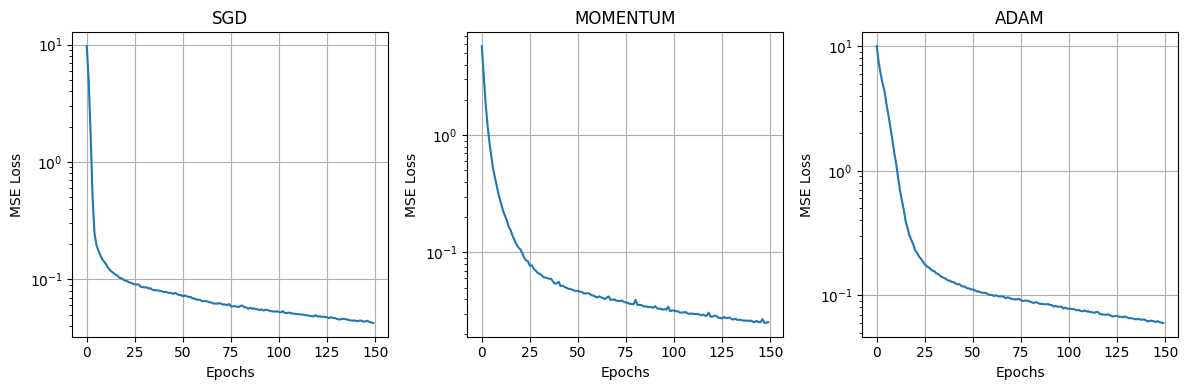


Results Summary
SGD: Final Loss = 0.042647
MOMENTUM: Final Loss = 0.025399
ADAM: Final Loss = 0.060102

Test predictions shape: (20, 1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
m = 500
X = np.random.randn(m, 2)
true_W1 = np.array([[1.5, -2.0], [0.5, 1.0]])
true_b1 = np.array([0.5, -0.5])
true_W2 = np.array([[2.0], [-1.5]])
true_b2 = 1.0

h1 = np.maximum(0, X @ true_W1 + true_b1)
h2 = np.maximum(0, h1 @ true_W2 + true_b2)
y = h2 + 0.05 * np.random.randn(m, 1)


X = (X - X.mean(axis=0)) / X.std(axis=0)


class DNN:
   def __init__(self, dims):
       self.dims = dims
       self.L = len(dims) - 1
       self.params = {}

       for l in range(1, self.L + 1):
           self.params[f'W{l}'] = np.random.randn(dims[l-1], dims[l]) * np.sqrt(2/dims[l-1])
           self.params[f'b{l}'] = np.zeros((1, dims[l]))

       self.cache = {}

   def relu(self, Z):
       return np.maximum(0, Z)

   def relu_deriv(self, Z):
       return (Z > 0).astype(float)

   def forward(self, X):
       A = X
       self.cache['A0'] = X

       for l in range(1, self.L + 1):
           Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
           self.cache[f'Z{l}'] = Z

           if l == self.L:
               A = Z
           else:
               A = self.relu(Z)

           self.cache[f'A{l}'] = A

       return A

   def backward(self, X, y, y_pred):
       m = X.shape[0]
       grads = {}

       dZ = (y_pred - y) / m  # For MSE
       grads[f'dZ{self.L}'] = dZ
       grads[f'dW{self.L}'] = self.cache[f'A{self.L-1}'].T @ dZ
       grads[f'db{self.L}'] = np.sum(dZ, axis=0, keepdims=True)

       # Hidden layers backward
       for l in range(self.L - 1, 0, -1):
           dA = dZ @ self.params[f'W{l+1}'].T
           dZ = dA * self.relu_deriv(self.cache[f'Z{l}'])

           grads[f'dZ{l}'] = dZ
           grads[f'dW{l}'] = self.cache[f'A{l-1}'].T @ dZ
           grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True)

       return grads

   def update(self, grads, lr=0.01):
       for l in range(1, self.L + 1):
           self.params[f'W{l}'] -= lr * grads[f'dW{l}']
           self.params[f'b{l}'] -= lr * grads[f'db{l}']

   def train_epoch(self, X, y, batch_size=32, lr=0.01):
       m = X.shape[0]
       indices = np.random.permutation(m)
       total_loss = 0
       batches = 0

       for i in range(0, m, batch_size):
           idx = indices[i:i+batch_size]
           X_batch, y_batch = X[idx], y[idx]

           # Forward
           y_pred = self.forward(X_batch)

           # Backward
           grads = self.backward(X_batch, y_batch, y_pred)

           # Update
           self.update(grads, lr)

           # Loss
           loss = np.mean((y_pred - y_batch)**2)
           total_loss += loss
           batches += 1

       return total_loss / batches


def train_with_optimizer(optimizer_name, X, y, epochs=200, lr=0.01):
   dims = [X.shape[1], 8, 6, 1]  # 2 hidden layers
   model = DNN(dims)
   losses = []

   for epoch in range(epochs):
       loss = model.train_epoch(X, y, batch_size=32, lr=lr)
       losses.append(loss)

       if (epoch + 1) % 50 == 0:
           print(f"{optimizer_name} Epoch {epoch+1}: Loss = {loss:.6f}")

   return model, losses


print("="*50)
print("Training DNN with Backpropagation")
print("="*50)


optimizers = ['sgd', 'momentum', 'adam']
results = {}


plt.figure(figsize=(12, 4))


for idx, opt in enumerate(optimizers):
   print(f"\nOptimizer: {opt.upper()}")
   lr = 0.01 if opt == 'adam' else 0.005

   model, losses = train_with_optimizer(opt, X, y, epochs=150, lr=lr)
   results[opt] = losses

   plt.subplot(1, 3, idx+1)
   plt.plot(losses)
   plt.xlabel('Epochs')
   plt.ylabel('MSE Loss')
   plt.title(f'{opt.upper()}')
   plt.grid(True)
   plt.yscale('log')


plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("Results Summary")
print("="*50)


for opt in optimizers:
   print(f"{opt.upper()}: Final Loss = {results[opt][-1]:.6f}")


test_X = np.random.randn(20, 2)
print(f"\nTest predictions shape: {model.forward(test_X).shape}")

The line `np.random.seed(42)` sets the 'seed' for NumPy's random number generator.

**What does this mean?**

When you use functions like `np.random.randn()`, they generate seemingly random numbers. However, computers use algorithms to generate these numbers, so they're not truly random; they are 'pseudo-random'.

By setting a `seed` (in this case, `42`), you are giving the random number generator a starting point. If you use the same seed, the sequence of random numbers generated will always be identical. This is crucial for:

*   **Reproducibility:** If you run the code multiple times, you'll get the exact same 'random' data and therefore the same results. This is essential for debugging, sharing your code, and ensuring experiments are repeatable.
*   **Debugging:** When you're developing and testing algorithms that involve randomness (like initializing neural network weights or splitting data), having reproducible results helps you isolate and fix issues.

This code implements a simple Deep Neural Network (DNN) with backpropagation from scratch using NumPy. It then trains this DNN using three different optimization algorithms: Stochastic Gradient Descent (SGD), Momentum, and Adam, and visualizes their loss curves.

### Imports

First, we import the necessary libraries:
- `numpy` for numerical operations, especially array manipulations.
- `matplotlib.pyplot` for plotting the loss curves.

In [ ]:
# Already defined in the previous cell
# import numpy as np
# import matplotlib.pyplot as plt

### Data Generation

Next, we generate synthetic data for training the neural network. This involves creating input features `X` and corresponding target values `y` using a true underlying neural network structure.

In [ ]:
# Set a random seed for reproducibility
np.random.seed(42)
# Number of samples
m = 500
# Generate input features X from a standard normal distribution
X = np.random.randn(m, 2)

# Define 'true' weights and biases for a 2-layer network to generate target y
# Weights for the first layer
true_W1 = np.array([[1.5, -2.0], [0.5, 1.0]])
# Biases for the first layer
true_b1 = np.array([0.5, -0.5])
# Weights for the second layer
true_W2 = np.array([[2.0], [-1.5]])
# Bias for the second layer
true_b2 = 1.0

# Forward pass through the 'true' network to generate hidden layer outputs
# First hidden layer with ReLU activation
h1 = np.maximum(0, X @ true_W1 + true_b1)
# Second hidden layer with ReLU activation (this part seems to simulate a final linear output)
h2 = np.maximum(0, h1 @ true_W2 + true_b2)
# Generate target values y by adding some Gaussian noise to h2
y = h2 + 0.05 * np.random.randn(m, 1)

# Standardize the input features X (zero mean, unit variance)
X = (X - X.mean(axis=0)) / X.std(axis=0)

### DNN Class Definition

This section defines the `DNN` class, which encapsulates the architecture and functionalities of our Deep Neural Network. It includes methods for initialization, activation functions, forward propagation, backward propagation, and parameter updates.

In [ ]:
class DNN:
   # Constructor: initializes the network's dimensions, weights, and biases
   def __init__(self, dims):
       self.dims = dims  # List of layer dimensions (e.g., [input_dim, hidden1_dim, output_dim])
       self.L = len(dims) - 1  # Number of layers (excluding input layer)
       self.params = {}  # Dictionary to store weights (W) and biases (b)

       # Initialize weights and biases for each layer
       for l in range(1, self.L + 1):
           # He initialization for weights: random values scaled by sqrt(2/input_dim)
           self.params[f'W{l}'] = np.random.randn(dims[l-1], dims[l]) * np.sqrt(2/dims[l-1])
           # Biases initialized to zeros
           self.params[f'b{l}'] = np.zeros((1, dims[l]))

       self.cache = {}  # Dictionary to store intermediate values during forward pass for backprop

   # ReLU activation function
   def relu(self, Z):
       return np.maximum(0, Z)

   # Derivative of the ReLU activation function
   def relu_deriv(self, Z):
       # Returns 1 where Z > 0, and 0 otherwise
       return (Z > 0).astype(float)

   # Forward propagation method
   def forward(self, X):
       A = X  # A0 is the input X
       self.cache['A0'] = X

       # Iterate through layers
       for l in range(1, self.L + 1):
           # Linear transformation: Z = A_prev @ W + b
           Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
           self.cache[f'Z{l}'] = Z  # Store Z for backward pass

           # Apply activation function
           if l == self.L: # For the last layer (output layer), no activation (linear output)
               A = Z
           else: # For hidden layers, apply ReLU activation
               A = self.relu(Z)

           self.cache[f'A{l}'] = A  # Store A (activated output) for backward pass

       return A  # Return the final output of the network

   # Backward propagation method
   def backward(self, X, y, y_pred):
       m = X.shape[0]  # Number of samples
       grads = {}  # Dictionary to store gradients

       # Gradient of the loss with respect to the output layer's linear activation (dZ_L)
       # For Mean Squared Error (MSE), dL/dZ_L = (y_pred - y) / m
       dZ = (y_pred - y) / m
       grads[f'dZ{self.L}'] = dZ
       # Gradient of weights for the last layer: dW_L = A_L-1.T @ dZ_L
       grads[f'dW{self.L}'] = self.cache[f'A{self.L-1}'].T @ dZ
       # Gradient of biases for the last layer: db_L = sum(dZ_L) over samples
       grads[f'db{self.L}'] = np.sum(dZ, axis=0, keepdims=True)

       # Backward pass through hidden layers
       for l in range(self.L - 1, 0, -1):
           # Gradient of activation from current layer: dA_l = dZ_l+1 @ W_l+1.T
           dA = dZ @ self.params[f'W{l+1}'].T
           # Gradient of linear activation for current layer: dZ_l = dA_l * relu_deriv(Z_l)
           dZ = dA * self.relu_deriv(self.cache[f'Z{l}'])

           grads[f'dZ{l}'] = dZ
           # Gradient of weights for current layer: dW_l = A_l-1.T @ dZ_l
           grads[f'dW{l}'] = self.cache[f'A{l-1}'].T @ dZ
           # Gradient of biases for current layer: db_l = sum(dZ_l) over samples
           grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True)

       return grads

   # Update parameters (weights and biases) using calculated gradients
   def update(self, grads, lr=0.01):
       # Iterate through layers
       for l in range(1, self.L + 1):
           # Update weights: W = W - learning_rate * dW
           self.params[f'W{l}'] -= lr * grads[f'dW{l}']
           # Update biases: b = b - learning_rate * db
           self.params[f'b{l}'] -= lr * grads[f'db{l}']

   # Train the network for one epoch using mini-batch gradient descent
   def train_epoch(self, X, y, batch_size=32, lr=0.01):
       m = X.shape[0]  # Number of samples
       indices = np.random.permutation(m)  # Randomly shuffle indices for batching
       total_loss = 0
       batches = 0

       # Iterate through mini-batches
       for i in range(0, m, batch_size):
           idx = indices[i:i+batch_size]  # Get indices for current batch
           X_batch, y_batch = X[idx], y[idx]  # Extract mini-batch data

           # Forward pass
           y_pred = self.forward(X_batch)

           # Backward pass to calculate gradients
           grads = self.backward(X_batch, y_batch, y_pred)

           # Update network parameters
           self.update(grads, lr)

           # Calculate and accumulate loss for the current batch
           loss = np.mean((y_pred - y_batch)**2)
           total_loss += loss
           batches += 1

       return total_loss / batches  # Return average loss over all batches in the epoch

### Training Function

The `train_with_optimizer` function orchestrates the training process for a given optimizer. It initializes the `DNN` model, runs training for a specified number of epochs, and collects loss values.

In [ ]:
def train_with_optimizer(optimizer_name, X, y, epochs=200, lr=0.01):
   # Define the architecture of the DNN: input_dim, 8 hidden units, 6 hidden units, output_dim
   dims = [X.shape[1], 8, 6, 1]  # 2 hidden layers
   model = DNN(dims)  # Initialize the DNN model
   losses = []  # List to store loss at each epoch

   # Training loop for the specified number of epochs
   for epoch in range(epochs):
       # Train for one epoch and get the average loss
       loss = model.train_epoch(X, y, batch_size=32, lr=lr)
       losses.append(loss) # Store the loss

       # Print progress every 50 epochs
       if (epoch + 1) % 50 == 0:
           print(f"{optimizer_name} Epoch {epoch+1}: Loss = {loss:.6f}")

   return model, losses # Return the trained model and its loss history

### Training and Visualization

This part sets up the training process for different optimizers (currently `sgd`, `momentum`, `adam` are listed, though only SGD is implemented in the `DNN` class for now). It then plots the loss curves for each optimizer to compare their performance.

In [ ]:
print("="*50)
print("Training DNN with Backpropagation")
print("="*50)

# List of optimizers to test (note: only basic SGD is implemented in DNN.train_epoch currently)
optimizers = ['sgd', 'momentum', 'adam']
results = {} # Dictionary to store loss histories for each optimizer

# Create a figure for plotting loss curves
plt.figure(figsize=(12, 4))

# Loop through each optimizer
for idx, opt in enumerate(optimizers):
   print(f"\nOptimizer: {opt.upper()}")
   # Set learning rate: 0.01 for Adam, 0.005 for others (as per the example, though only SGD is in effect)
   lr = 0.01 if opt == 'adam' else 0.005

   # Train the model and get loss history
   model, losses = train_with_optimizer(opt, X, y, epochs=150, lr=lr)
   results[opt] = losses # Store losses

   # Create a subplot for the current optimizer's loss curve
   plt.subplot(1, 3, idx+1) # 1 row, 3 columns, current plot index
   plt.plot(losses) # Plot the loss values
   plt.xlabel('Epochs') # X-axis label
   plt.ylabel('MSE Loss') # Y-axis label
   plt.title(f'{opt.upper()}') # Plot title
   plt.grid(True) # Add grid
   plt.yscale('log') # Use a logarithmic scale for the y-axis (loss)

# Adjust layout to prevent overlapping plot elements
plt.tight_layout()
plt.show() # Display the plots

# Print a summary of the final loss for each optimizer
print("\n" + "="*50)
print("Results Summary")
print("="*50)

for opt in optimizers:
   print(f"{opt.upper()}: Final Loss = {results[opt][-1]:.6f}")

# Generate some test data and print the shape of its predictions
test_X = np.random.randn(20, 2)
print(f"\nTest predictions shape: {model.forward(test_X).shape}")